# MNIST Handwritten Digit Recognition

Notebook version of the Poetry pipeline. It downloads and caches MNIST, visualizes digits, trains KNN, logistic regression, and a neural network, then writes figures and CSV results to `artifacts/`.

In [1]:
from pathlib import Path
from types import SimpleNamespace

import pandas as pd
from IPython.display import Image, display

from mnist_pipeline.pipeline import (
    build_config,
    generate_embedding_artifacts,
    load_processed_dataset,
    save_run_manifest,
    save_sample_grid,
    train_and_evaluate_models,
)


In [2]:
project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

args = SimpleNamespace(
    project_root=project_root,
    pca_sample_size=5000,
    tsne_sample_size=3000,
    random_state=42,
)
config = build_config(args)
config


PipelineConfig(project_root=PosixPath('/Users/bob/Desktop/MNIST'), raw_data_dir=PosixPath('/Users/bob/Desktop/MNIST/data/raw'), processed_data_dir=PosixPath('/Users/bob/Desktop/MNIST/data/processed'), raw_dataset_path=PosixPath('/Users/bob/Desktop/MNIST/data/raw/mnist.npz'), processed_dataset_path=PosixPath('/Users/bob/Desktop/MNIST/data/processed/mnist_flattened.npz'), artifacts_dir=PosixPath('/Users/bob/Desktop/MNIST/artifacts'), figures_dir=PosixPath('/Users/bob/Desktop/MNIST/artifacts/figures'), results_dir=PosixPath('/Users/bob/Desktop/MNIST/artifacts/results'), pca_sample_size=5000, tsne_sample_size=3000, random_state=42)

In [3]:
X_train, X_test, y_train, y_test = load_processed_dataset(config=config, force_refresh=False)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(60000, 784) (10000, 784) (60000,) (10000,)


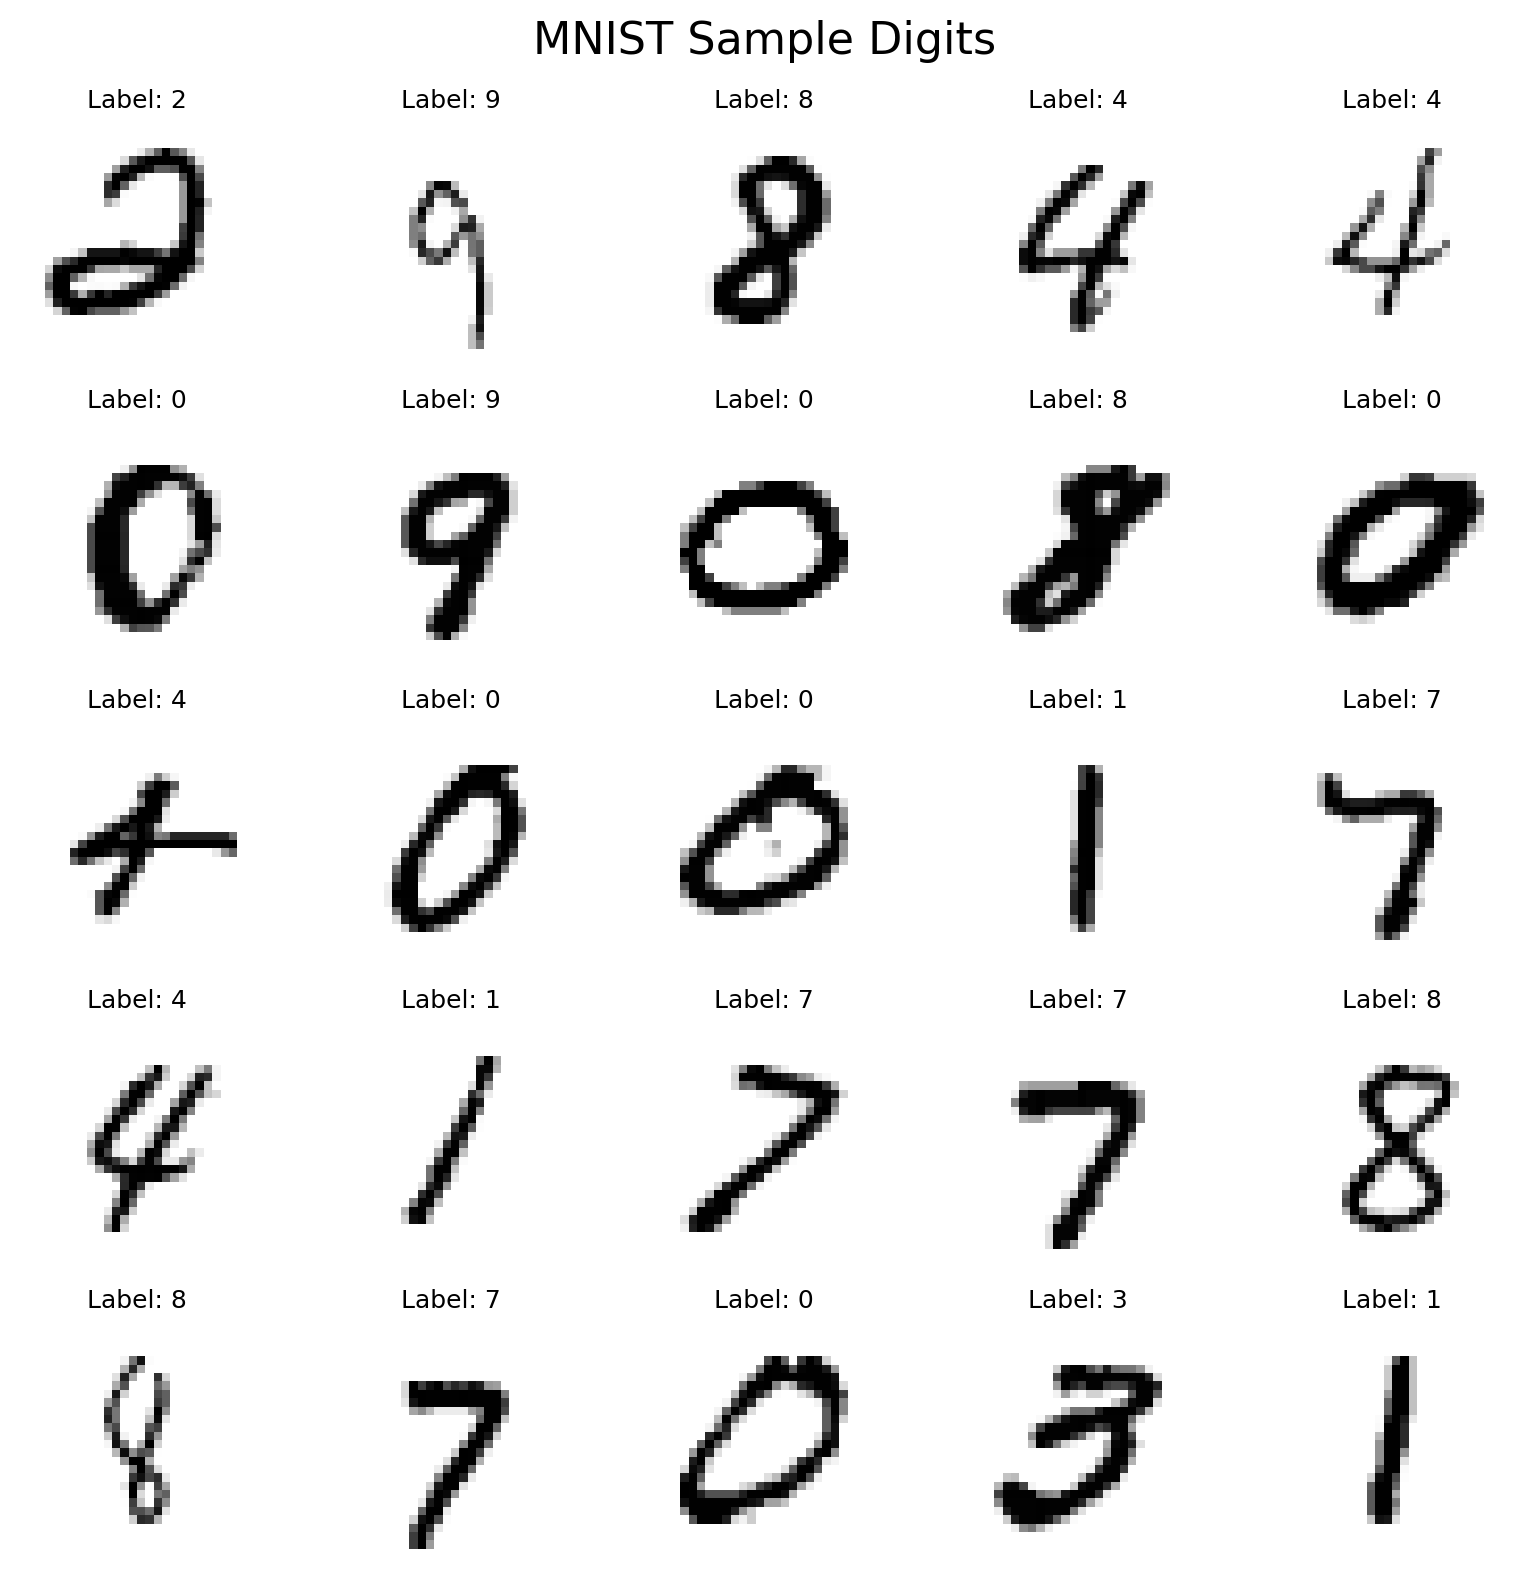

In [4]:
sample_path = config.figures_dir / "sample_digits.png"
save_sample_grid(X_train, y_train, sample_path, random_state=config.random_state)
display(Image(filename=str(sample_path)))


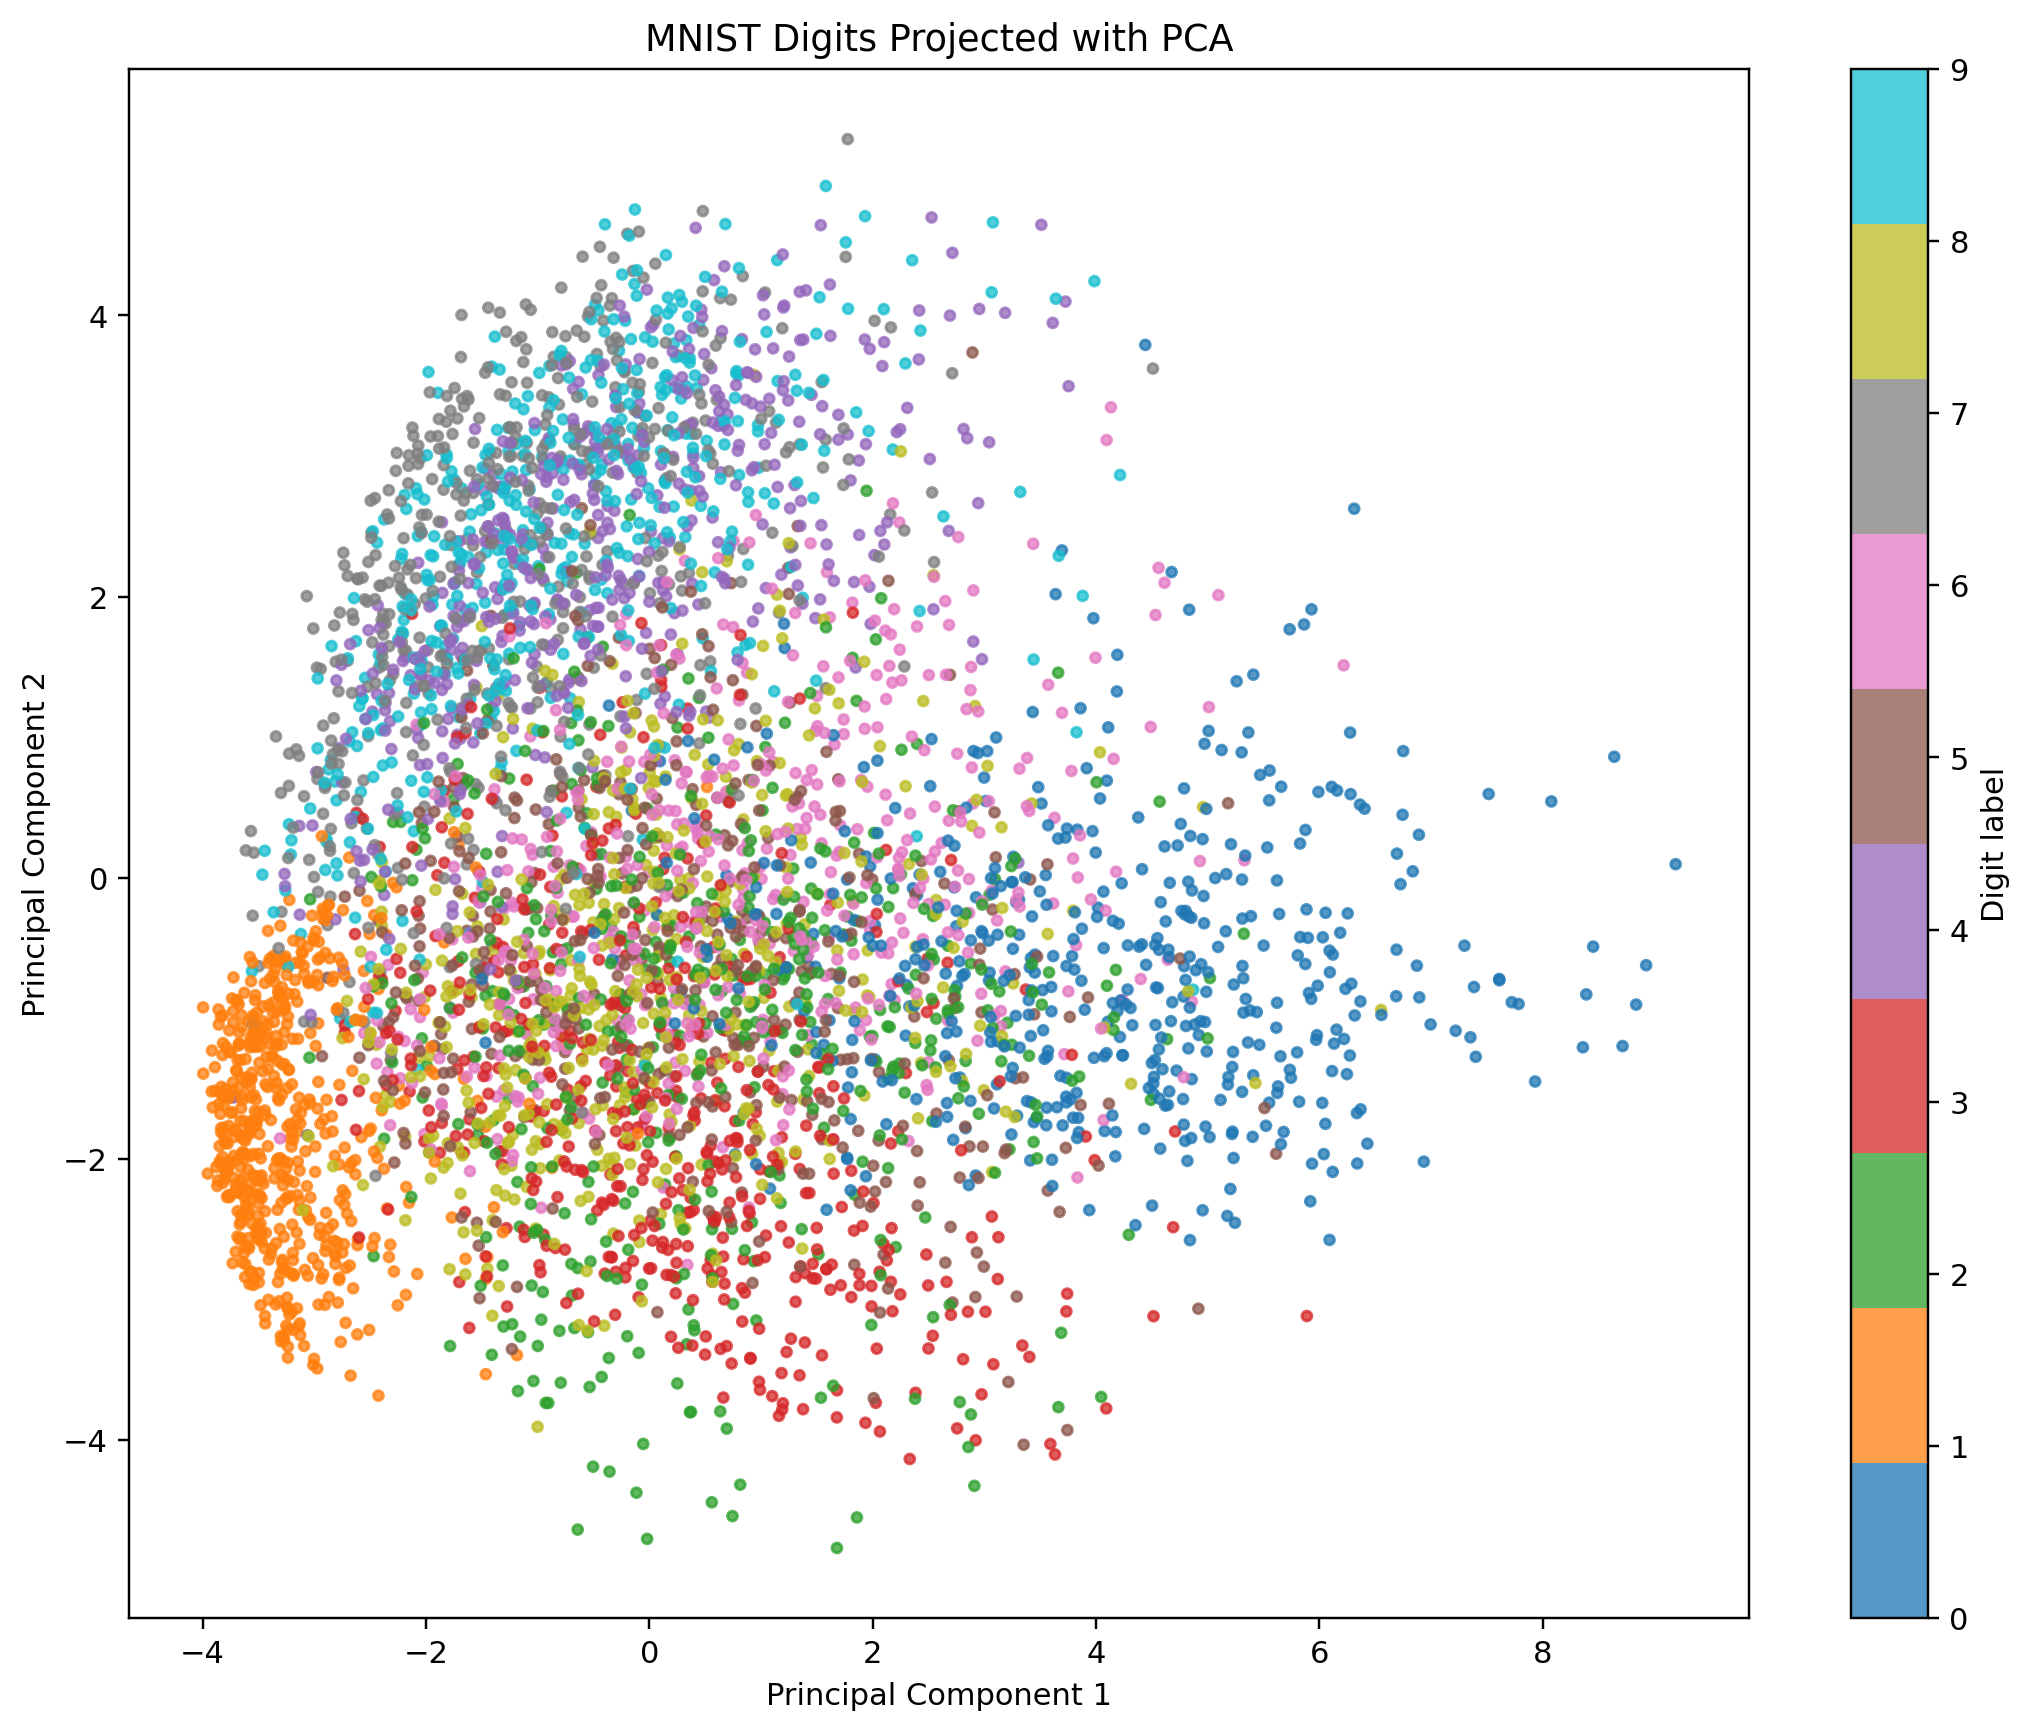

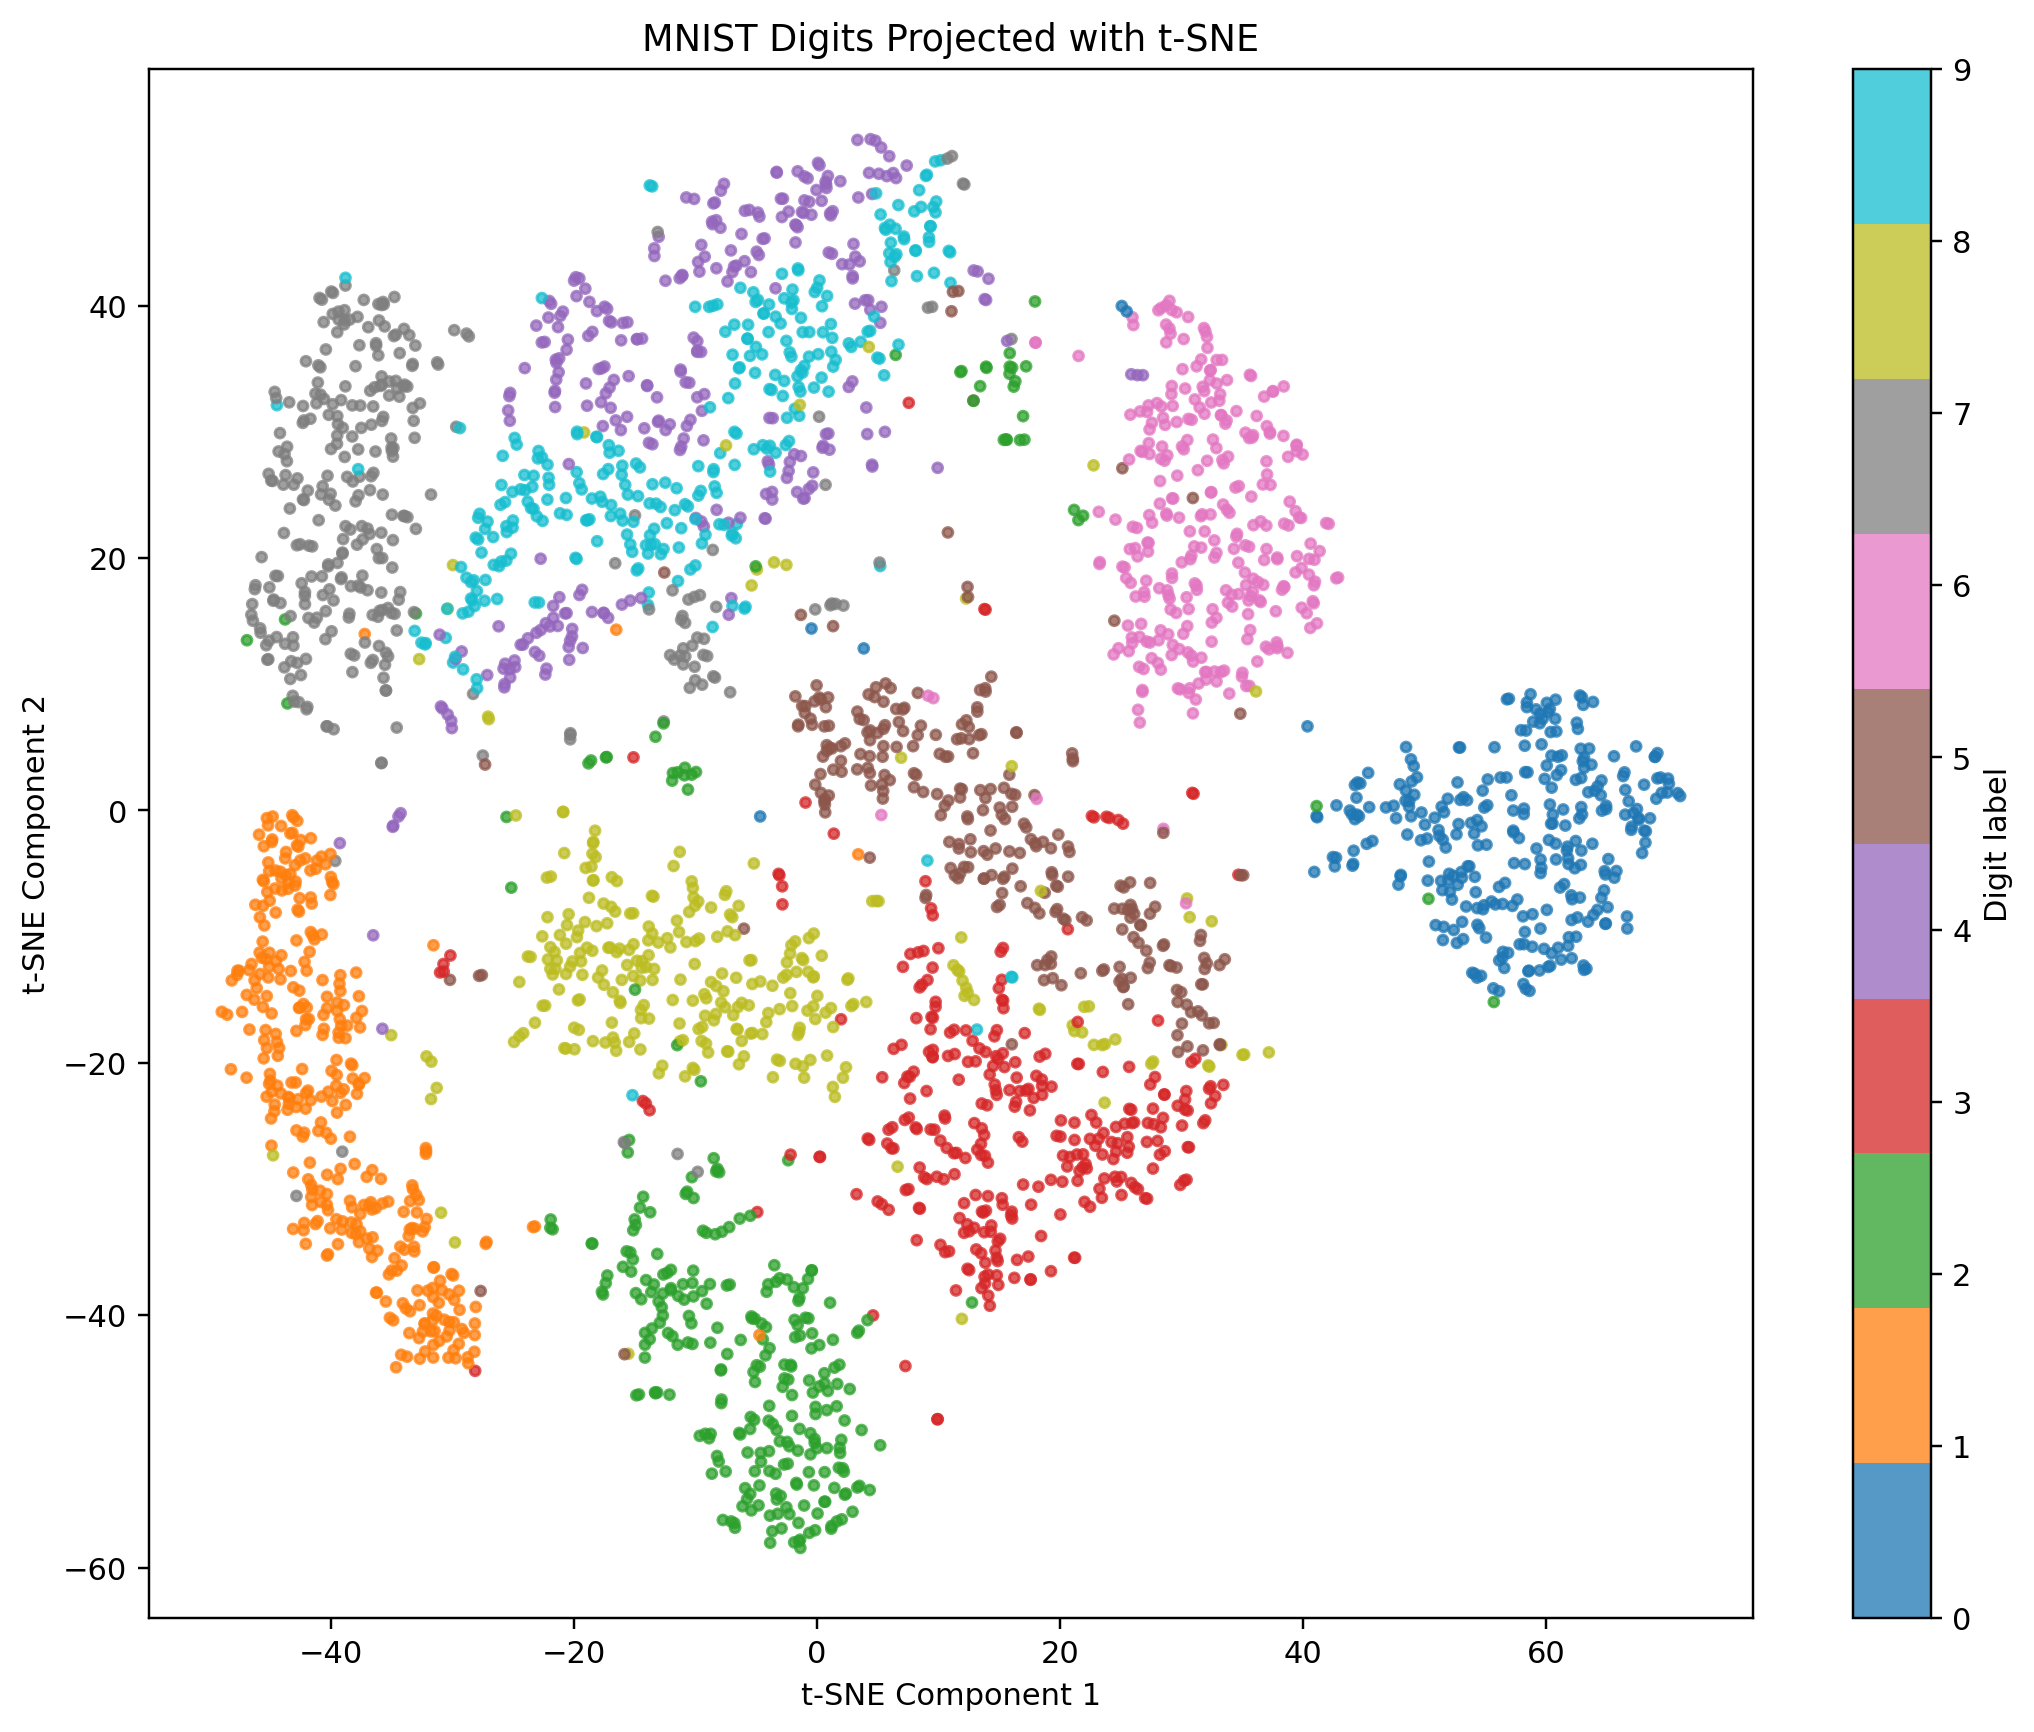

{'pca_explained_variance_ratio': 0.1692299097776413}

In [5]:
embedding_metadata = generate_embedding_artifacts(X_train, y_train, config)
display(Image(filename=str(config.figures_dir / "digits_pca_2d.png")))
display(Image(filename=str(config.figures_dir / "digits_tsne_2d.png")))
embedding_metadata


In [6]:
metrics_frame = train_and_evaluate_models(X_train, X_test, y_train, y_test, config)
save_run_manifest(config, metrics_frame, embedding_metadata, y_train, y_test)
metrics_frame


,model,train_seconds,predict_seconds,accuracy,precision_macro,recall_macro,f1_macro
2,neural_network,4.272,0.004,0.9788,0.97875,0.97861,0.97866
0,knn,0.018,2.103,0.9691,0.96949,0.96876,0.96899
1,logistic_regression,5.844,0.009,0.9260,0.92504,0.92493,0.92491


In [7]:
predictions_path = config.results_dir / "test_predictions.csv"
metrics_path = config.results_dir / "model_metrics.csv"

pd.read_csv(metrics_path)


,model,train_seconds,predict_seconds,accuracy,precision_macro,recall_macro,f1_macro
0,neural_network,4.272,0.004,0.9788,0.97875,0.97861,0.97866
1,knn,0.018,2.103,0.9691,0.96949,0.96876,0.96899
2,logistic_regression,5.844,0.009,0.9260,0.92504,0.92493,0.92491


knn_confusion_matrix.png


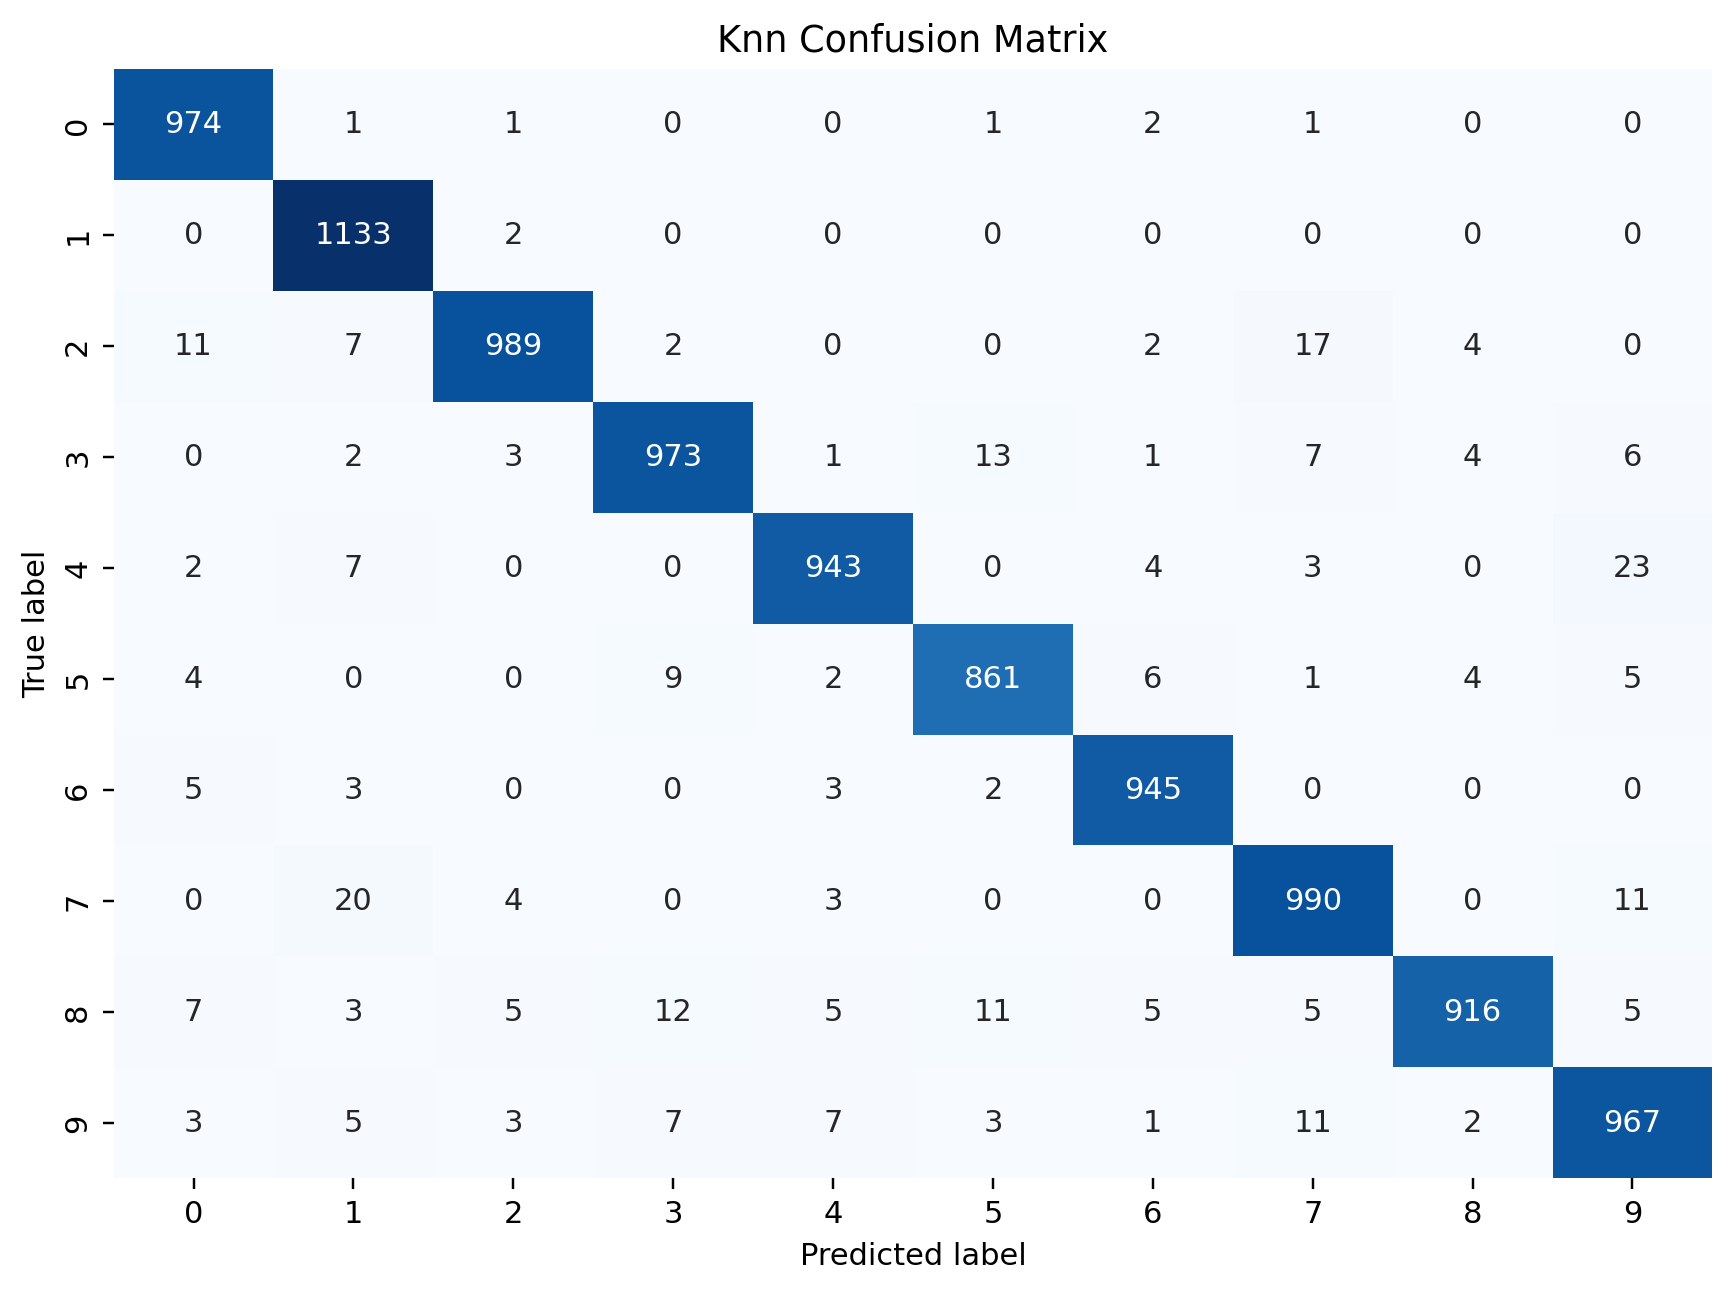

logistic_regression_confusion_matrix.png


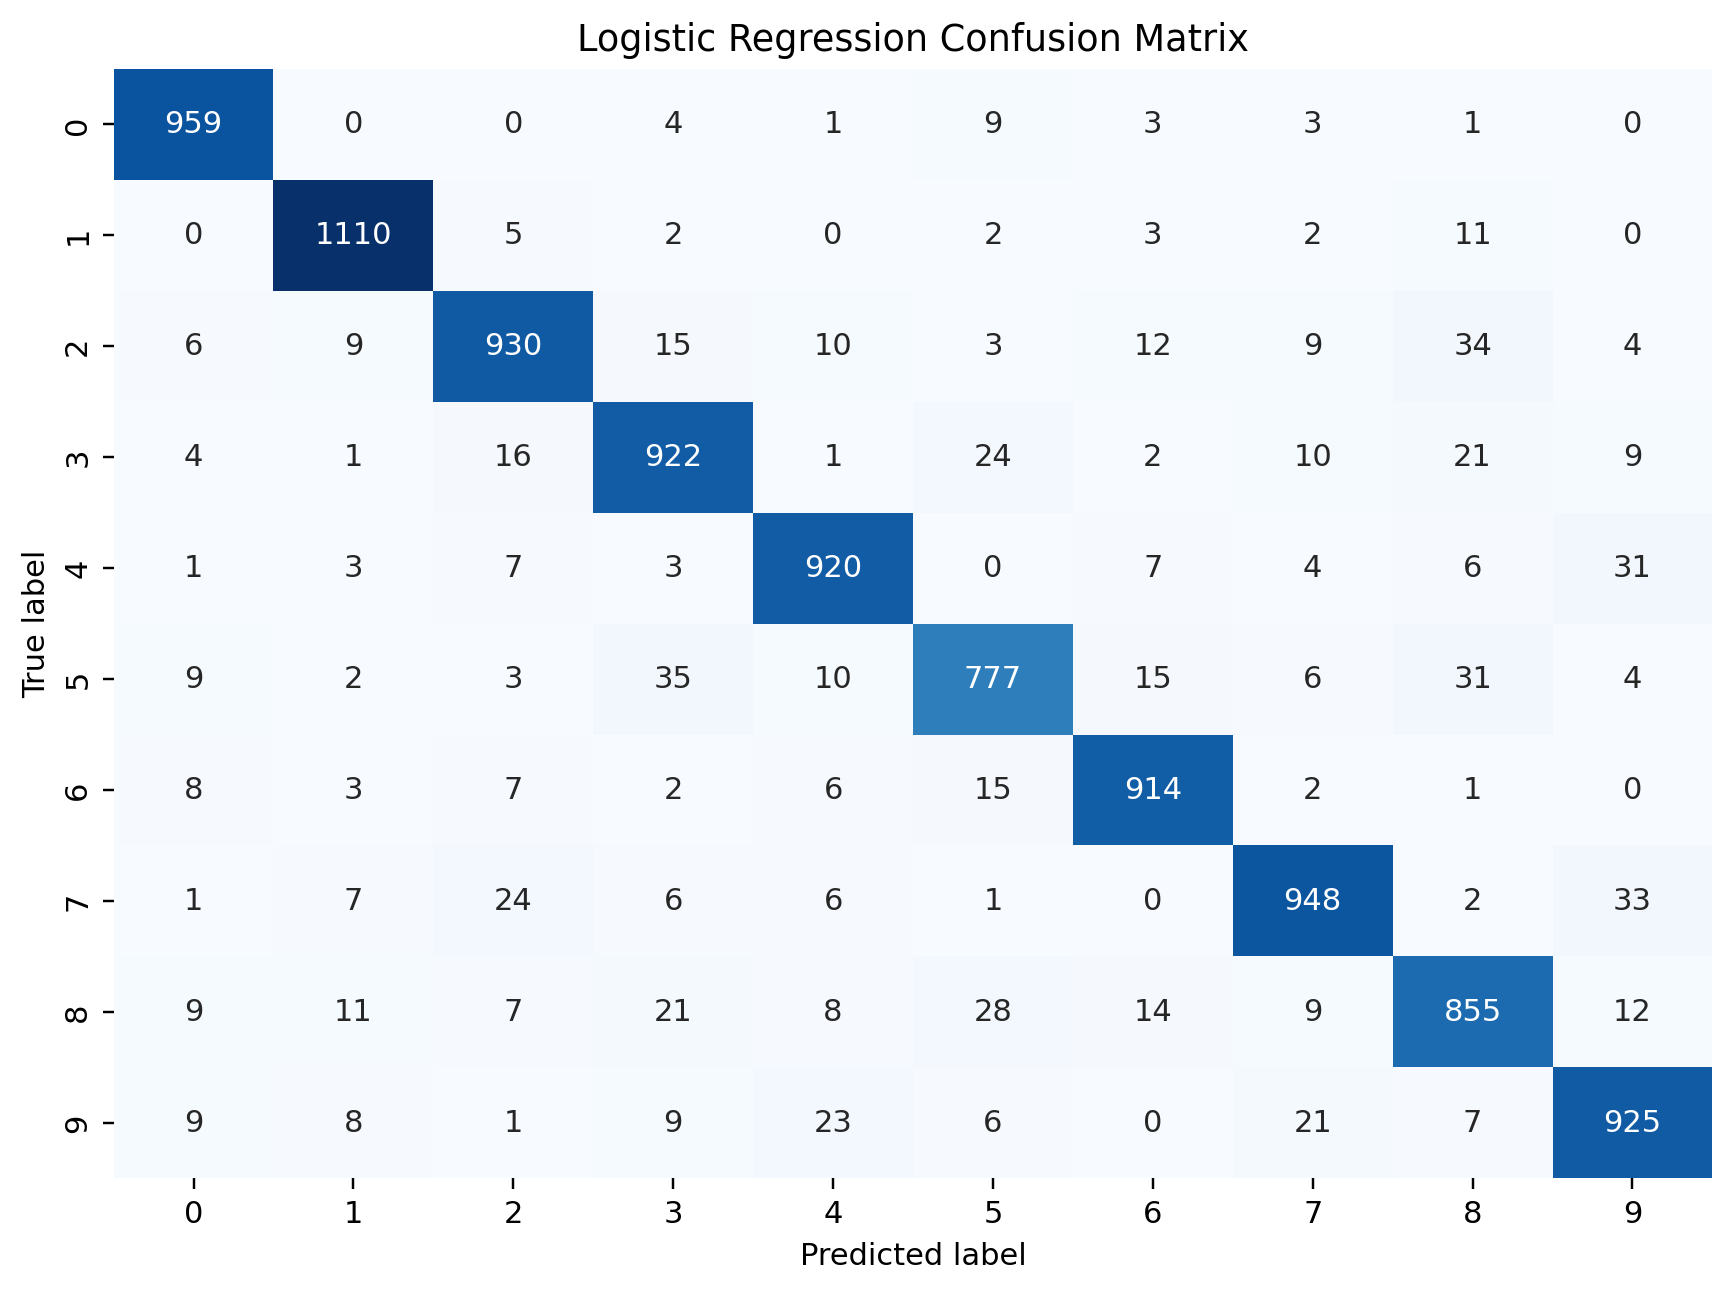

neural_network_confusion_matrix.png


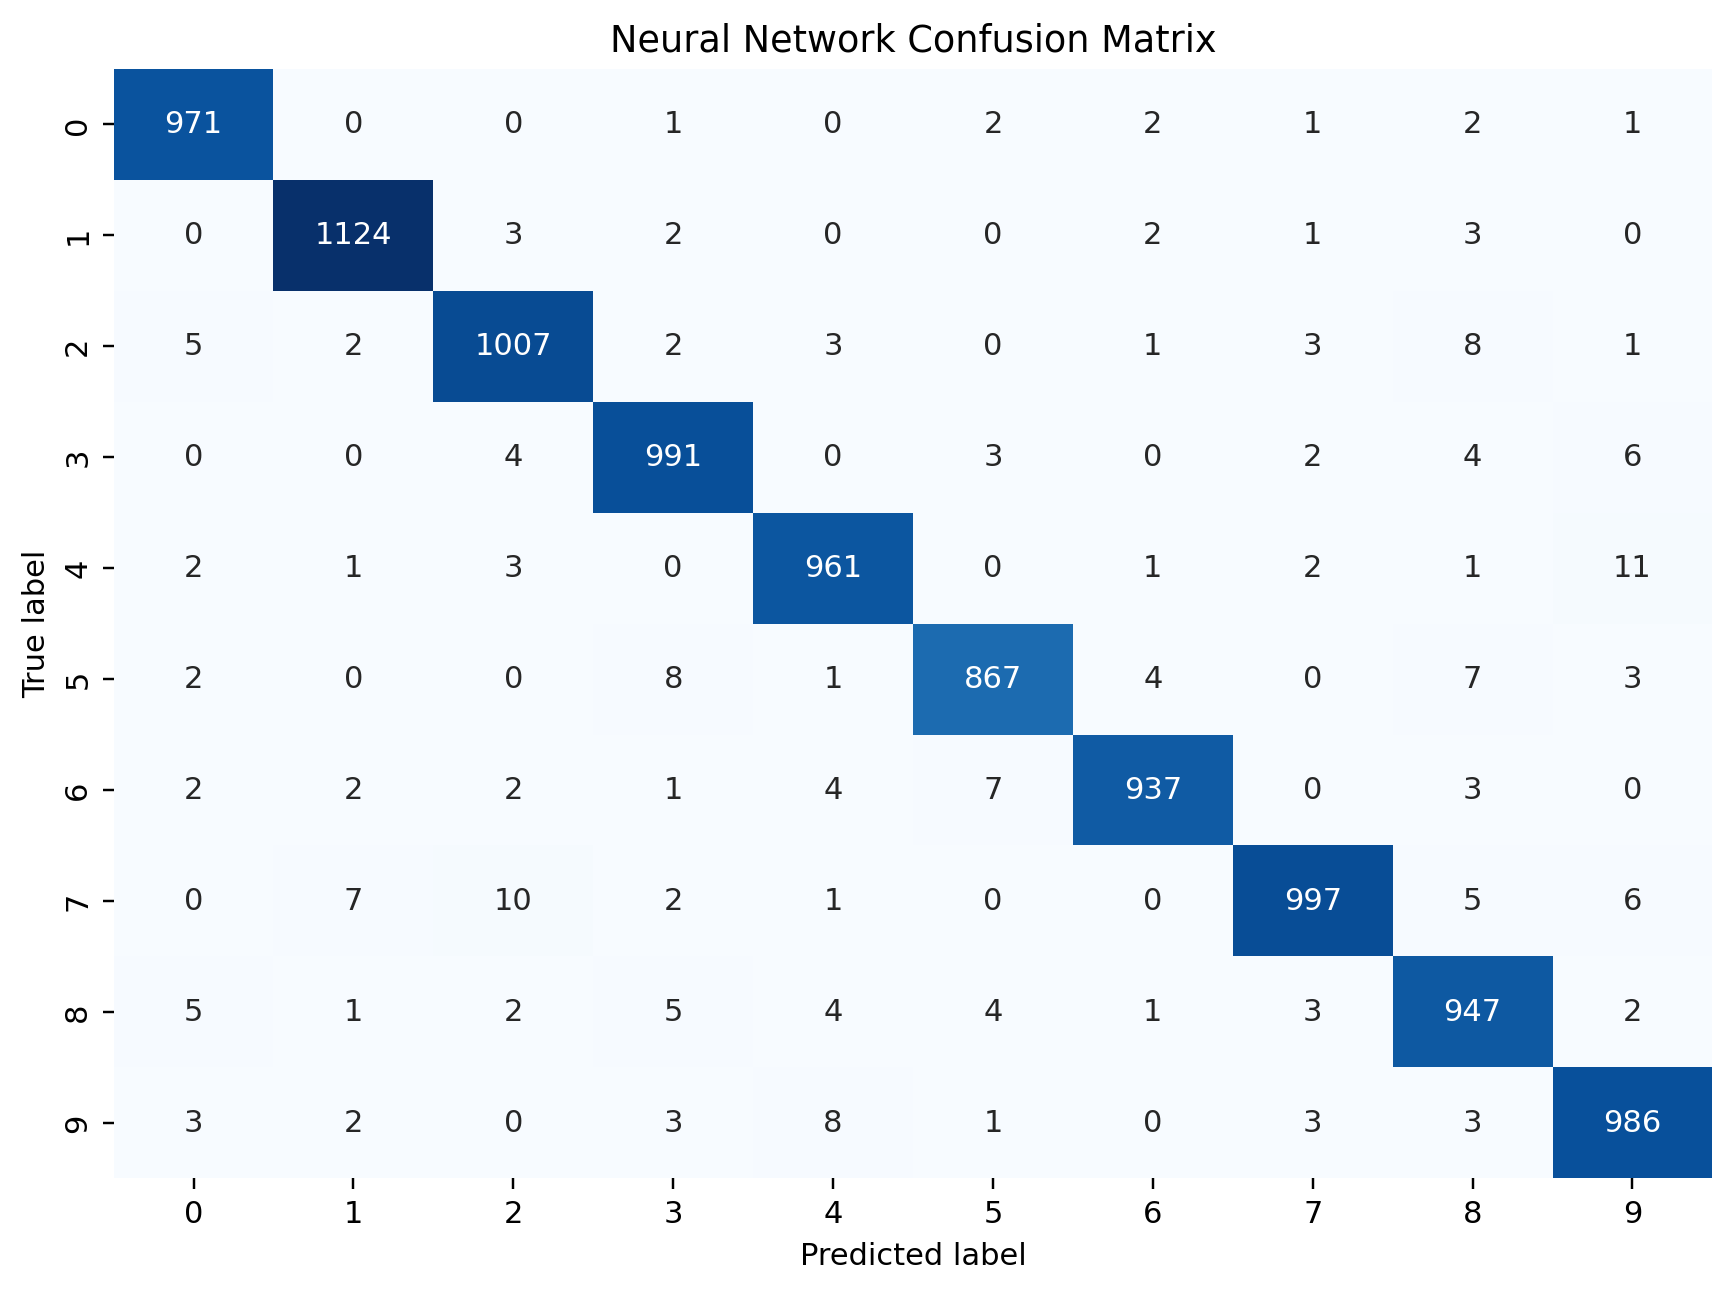

In [8]:
for figure_path in sorted(config.figures_dir.glob("*_confusion_matrix.png")):
    print(figure_path.name)
    display(Image(filename=str(figure_path)))


In [9]:
print("Artifacts:")
for path in sorted(config.figures_dir.iterdir()):
    print(path.relative_to(project_root))
for path in sorted(config.results_dir.iterdir()):
    print(path.relative_to(project_root))


Artifacts:
artifacts/figures/digits_pca_2d.png
artifacts/figures/digits_tsne_2d.png
artifacts/figures/knn_confusion_matrix.png
artifacts/figures/logistic_regression_confusion_matrix.png
artifacts/figures/neural_network_confusion_matrix.png
artifacts/figures/sample_digits.png
artifacts/results/knn_classification_report.csv
artifacts/results/logistic_regression_classification_report.csv
artifacts/results/model_metrics.csv
artifacts/results/neural_network_classification_report.csv
artifacts/results/run_manifest.json
artifacts/results/test_predictions.csv
